# Task 2 — Stock Price Prediction (AAPL, Linear Regression)

## Goal
- Download last **2 years** of `AAPL` data with `yfinance`
- Create `Target` = **next-day close**
- Train a **Linear Regression** model
- Plot **Actual vs Predicted** prices

⚠️ Note: This is a baseline demonstration. Stock prices are noisy and not stationary; a simple linear model will not be production-grade.


In [18]:
import warnings
warnings.filterwarnings("ignore")

from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (12, 6)

TICKER = "AAPL"
PERIOD = "2y"  # last 2 years
INTERVAL = "1d"

## Download data (yfinance)
We fetch daily OHLCV bars. `Auto-adjust` is disabled to keep raw `Close` consistent.


In [19]:
def flatten_yfinance_columns(frame: pd.DataFrame) -> pd.DataFrame:
    """Normalize yfinance columns to simple strings.

    Handles:
- MultiIndex columns: ('Close','AAPL')
- Tuple columns after reset_index: ('Date','')
    """
    frame = frame.copy()

    if isinstance(frame.columns, pd.MultiIndex):
        frame.columns = frame.columns.get_level_values(0)
        return frame

    # Sometimes pandas stores tuple-like columns in a plain Index of tuples
    if any(isinstance(c, tuple) for c in frame.columns):
        frame.columns = [c[0] if isinstance(c, tuple) and len(c) > 0 else c for c in frame.columns]
    return frame

df = yf.download(
    TICKER,
    period=PERIOD,
    interval=INTERVAL,
    auto_adjust=False,
    progress=False,
)

df = flatten_yfinance_columns(df)

# Keep Date as a column for easier plotting
df = df.reset_index()
df = flatten_yfinance_columns(df)

df.head(), df.shape

(Price       Date   Adj Close       Close        High         Low        Open  \
 0     2024-04-08  166.930801  168.449997  169.199997  168.240005  169.029999   
 1     2024-04-09  168.139786  169.669998  170.080002  168.350006  168.699997   
 2     2024-04-10  166.266830  167.779999  169.089996  167.110001  168.800003   
 3     2024-04-11  173.461334  175.039993  175.460007  168.160004  168.339996   
 4     2024-04-12  174.957733  176.550003  178.360001  174.210007  174.259995   
 
 Price     Volume  
 0       37425500  
 1       42373800  
 2       49709300  
 3       91070300  
 4      101670900  ,
 (500, 7))

## Basic checks (EDA-lite)
We verify schema, missing values, and date ordering.

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       500 non-null    datetime64[ns]
 1   Adj Close  500 non-null    float64       
 2   Close      500 non-null    float64       
 3   High       500 non-null    float64       
 4   Low        500 non-null    float64       
 5   Open       500 non-null    float64       
 6   Volume     500 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 27.5 KB


In [21]:
display(df.describe(include="all"))
display(df.isna().sum())

# Ensure sorted by date (important for time-based splits)
df = df.sort_values("Date").reset_index(drop=True)
df[["Date", "Close"]].tail()

Price,Date,Adj Close,Close,High,Low,Open,Volume
count,500,500.000000,500.000000,500.000000,500.000000,500.000000,5.000000e+02
mean,2025-04-05 06:20:09.600000,229.057721,229.966360,232.272240,227.514360,229.774340,5.388641e+07
min,2024-04-08 00:00:00,163.511917,165.000000,166.399994,164.080002,165.350006,1.791060e+07
25%,2024-10-03 18:00:00,210.626549,211.267502,213.625000,208.914997,210.965000,3.975142e+07
50%,2025-04-05 12:00:00,226.999962,228.239998,230.419998,226.089996,228.495003,4.720580e+07
75%,2025-10-03 18:00:00,251.527504,251.779999,254.857502,249.107498,252.129997,5.753582e+07
max,2026-04-06 00:00:00,285.922455,286.190002,288.619995,283.299988,286.200012,3.186799e+08
std,NaN,27.505810,27.195029,27.257128,27.114553,27.278352,2.713345e+07


,0
Price,
Date,0
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0


Price,Date,Close
495,2026-03-30,246.630005
496,2026-03-31,253.789993
497,2026-04-01,255.630005
498,2026-04-02,255.919998
499,2026-04-06,258.859985


## Preprocessing
Create a supervised learning target:
- `Target = Close.shift(-1)` (next trading day's close)

We drop the final row since it has no next-day target.

In [22]:
# In case you run this cell independently, normalize columns again
df = flatten_yfinance_columns(df)

# Validate expected columns before creating the target
required_cols = {"Date", "Open", "High", "Low", "Close", "Volume"}
missing = required_cols - set(df.columns)
if missing:
    raise KeyError(
        f"Missing expected columns from yfinance download: {sorted(missing)}. "
        f"Columns present: {list(df.columns)}"
    )

# Create next-day closing price target in a single safe transform
df = (
    df.copy()
    .assign(Target=lambda d: d["Close"].shift(-1))
    .dropna(subset=["Target"])
    .reset_index(drop=True)
)

df[["Date", "Close", "Target"]].head()

Price,Date,Close,Target
0,2024-04-08,168.449997,169.669998
1,2024-04-09,169.669998,167.779999
2,2024-04-10,167.779999,175.039993
3,2024-04-11,175.039993,176.550003
4,2024-04-12,176.550003,172.690002


## Feature selection
Baseline features use same-day market information:
- `Open`, `High`, `Low`, `Close`, `Volume`

We keep `Date` only for plotting (not as a numeric feature).

In [23]:
feature_cols = ["Open", "High", "Low", "Close", "Volume"]
target_col = "Target"

X = df[feature_cols].astype(float)
y = df[target_col].astype(float)

X.head(), y.head()

(Price        Open        High         Low       Close       Volume
 0      169.029999  169.199997  168.240005  168.449997   37425500.0
 1      168.699997  170.080002  168.350006  169.669998   42373800.0
 2      168.800003  169.089996  167.110001  167.779999   49709300.0
 3      168.339996  175.460007  168.160004  175.039993   91070300.0
 4      174.259995  178.360001  174.210007  176.550003  101670900.0,
 0    169.669998
 1    167.779999
 2    175.039993
 3    176.550003
 4    172.690002
 Name: Target, dtype: float64)

## Train/test split (time-based)
We avoid shuffling for time series. We'll use the last 20% as a simple test set.

In [24]:
split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = df.loc[split_idx:, "Date"]

len(X_train), len(X_test)

(399, 100)

## Model: Linear Regression
Train a linear regression baseline and evaluate on the test range.

In [25]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
# Version-safe RMSE (some sklearn versions don't support squared=False)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2:  {r2:.4f}")

MAE:  2.5151
RMSE: 3.5467
R^2:  0.8762


## Visualization: Actual vs Predicted
We plot the next-day close target (`y_test`) vs predictions on the same date index.

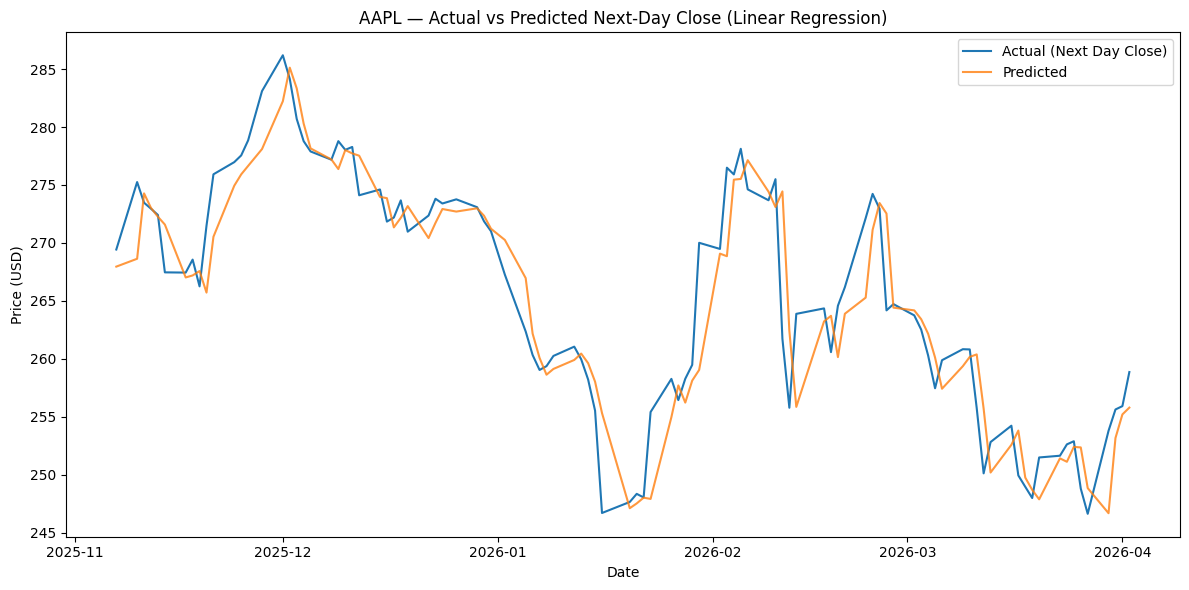

In [26]:
plot_df = pd.DataFrame(
    {
        "Date": dates_test.values,
        "Actual_NextClose": y_test.values,
        "Predicted_NextClose": y_pred,
    }
)

plt.figure(figsize=(12, 6))
plt.plot(plot_df["Date"], plot_df["Actual_NextClose"], label="Actual (Next Day Close)")
plt.plot(plot_df["Date"], plot_df["Predicted_NextClose"], label="Predicted", alpha=0.8)
plt.title(f"{TICKER} — Actual vs Predicted Next-Day Close (Linear Regression)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()